In [339]:
import mrc #All functionality for the MRC is included in this library
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sg 
import time

# mrr = mrc.Console(frequency=22.05e6)              # Connect to the MRR and initialize the system
mrr = mrc.Console(frequency=8.05e6)      # Connect to the MRR and initialize the system

Connected to COM3


In [316]:
%matplotlib widget
sos = sg.butter(20, 5e3, 'low', fs=100e3, output='sos')

## SE On CAS Magnet

Setting Coil Strength to 3 Counts/Hz
Setting Frequency to 8061000.0
Loading Sequence... Done.
Running Sequence
Received Bytes: 3008



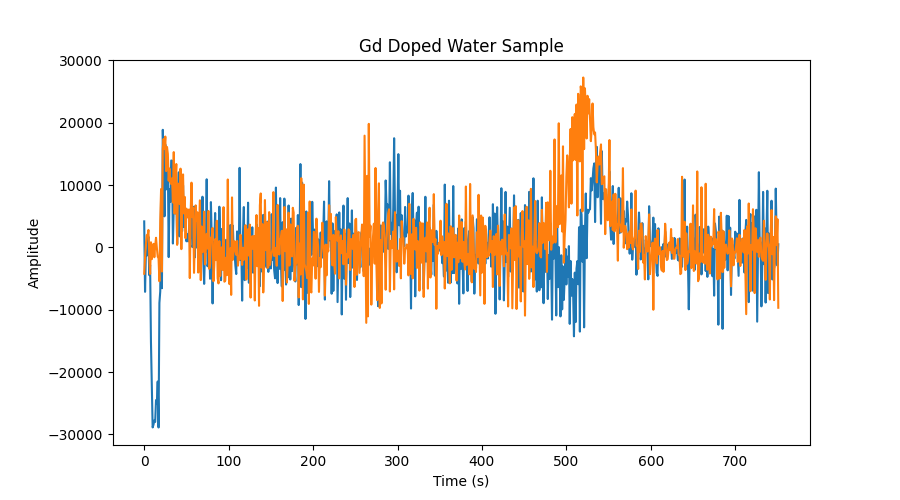

In [128]:
mrr.amp(3)
# mrr.freq(8.06e6)
mrr.freq(8.061e6) # probe reading is 1911
mrr.run(mrc.build_spinecho(5e-3, 100e-6, 150e-6))
rx_data1 = sg.sosfiltfilt(sos, mrr.rx_data * np.exp(-1j*(np.angle(mrr.rx_data[19]) + np.pi/2)))
# rx_data1 = mrr.rx_data * np.exp(-1j*(np.angle(mrr.rx_data[19]) + np.pi/2))

cpmg_fig = plt.figure(figsize=(9,5))                                      # Plot the results
# plt.plot(np.real(rx_data1))
# plt.plot(np.imag(rx_data1))
plt.plot(np.real(mrr.rx_data))
plt.plot(np.imag(mrr.rx_data))
# plt.ylim([-15000,15000])
# plt.xlim([0,2000])
plt.title("Gd Doped Water Sample")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
# plt.legend(["$T_2$ = %0.2f" % (mrc.get_t2(echo_amplitudes, 3e-3))]) # Put the calculated T2 in the legend
plt.show()  

## Run on Medium Magnet and MM Probe

Setting Coil Strength to 7 Counts/Hz
Setting Frequency to 8046000.0
Loading Sequence... Done.
Running Sequence
Received Bytes: 4800



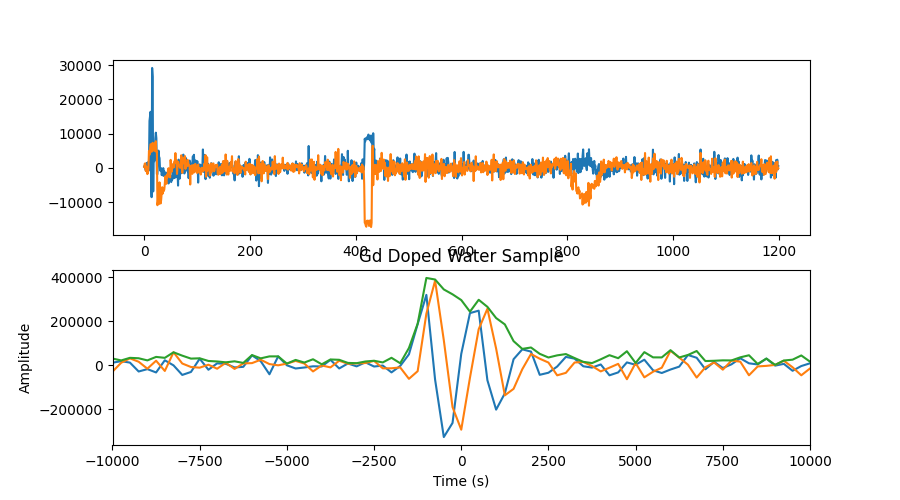

In [338]:
mrr.amp(7)
# mrr.freq(8.065e6)
mrr.freq(8.046e6) # probe reading is 1866. Grounding magnet to probe is very good for noise
mrr.run(mrc.build_spinecho(8e-3, 150e-6, 150e-6))
rx_data1 = sg.sosfiltfilt(sos, mrr.rx_data * np.exp(-1j*(np.angle(mrr.rx_data[19]) + np.pi/2)))
# rx_data1 = mrr.rx_data * np.exp(-1j*(np.angle(mrr.rx_data[19]) + np.pi/2))

cpmg_fig, ax = plt.subplots(2,1,figsize=(9,5))                                      # Plot the results
# plt.plot(np.real(rx_data1))
# plt.plot(np.imag(rx_data1))
ax[0].plot(np.real(mrr.rx_data))
ax[0].plot(np.imag(mrr.rx_data))

ft = np.fft.fft(np.fft.fftshift(mrr.rx_data[700:1100]))
fs = np.fft.fftfreq(len(ft), d=1/100e3)
ax[1].plot(np.fft.fftshift(fs), np.real(np.fft.fftshift(ft)))
ax[1].plot(np.fft.fftshift(fs), np.imag(np.fft.fftshift(ft)))
ax[1].plot(np.fft.fftshift(fs), np.abs(np.fft.fftshift(ft)))
ax[1].set_xlim([-10000,10000])
# plt.ylim([-15000,15000])
# plt.xlim([0,2000])
plt.title("Gd Doped Water Sample")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
# plt.legend(["$T_2$ = %0.2f" % (mrc.get_t2(echo_amplitudes, 3e-3))]) # Put the calculated T2 in the legend
plt.show()  

In [246]:
np.save("grad385.npy", mrr.rx_data)

Setting Coil Strength to 3 Counts/Hz
Loading Sequence... Done.
Running Sequence
Received Bytes: 320448

Loading Sequence... Done.
Running Sequence
Received Bytes: 1856



RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.

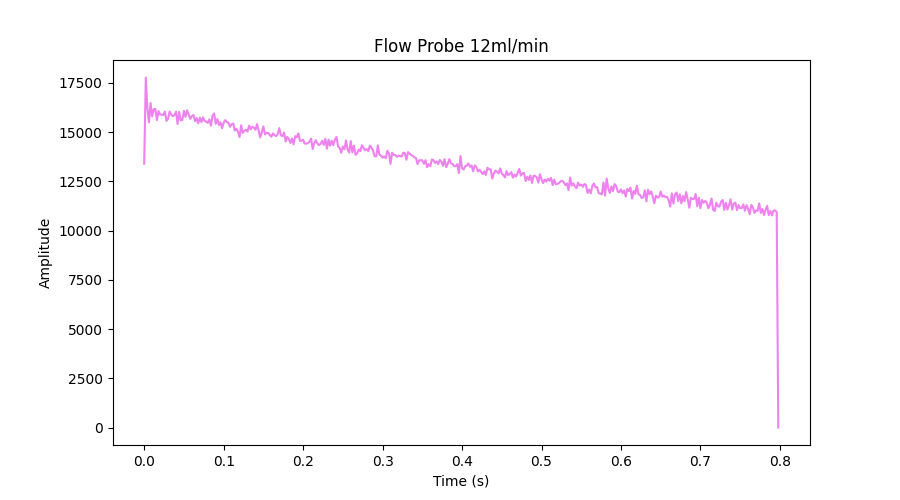

In [20]:
mrr.amp(3)
t_echo = 2e-3
num_echoes = 400
onlystatic = True
t90 = 150e-6
t180 = 150e-6

mrr.run_cpmg(num_echoes, t_echo, t90, t180)
echo_times = np.arange(0, t_echo * num_echoes, t_echo)
mrr.rx_data = mrr.rx_data * np.exp(-1j*(np.angle(mrr.rx_data[19]) + np.pi/2))
filtdata = sg.sosfiltfilt(sos, mrr.rx_data)
static_echo_amplitudes = mrc.get_echo_amplitudes(filtdata, num_echoes, t_echo, t90, use_real=False)
mrr.run(mrc.build_spinecho(3e-3, 150e-6, 150e-6))
if not onlystatic:
    time.sleep(15)
    echo_times, forward_echo_amplitudes = mrr.run_cpmg(num_echoes, t_echo, t90, t180)
    mrr.run(mrc.build_spinecho(3e-3, t90, t180))
    time.sleep(15)
    echo_times, reverse_echo_amplitudes = mrr.run_cpmg(num_echoes, t_echo, t90, t180)
    # mrr.run(mrc.build_spinecho(3e-3, 300e-6, 300e-6))

cpmg_fig = plt.figure(figsize=(9,5))                                      # Plot the results
# plt.plot(echo_times, echo_amplitudes, color='violet')
plt.plot(echo_times, static_echo_amplitudes, color='violet')
if not onlystatic:
    plt.plot(echo_times, forward_echo_amplitudes, color='purple')
    plt.plot(echo_times, reverse_echo_amplitudes, color='blueviolet')
plt.title("Flow Probe 12ml/min")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
if(onlystatic):
    plt.legend(["Static $T_2$ = %0.4f" % (mrc.get_t2(static_echo_amplitudes[50:], t_echo))])
else:
    plt.legend(["Static $T_2$ = %0.2f" % (mrc.get_t2(static_echo_amplitudes, t_echo)),
                "Forward $T_2$ = %0.2f" % (mrc.get_t2(forward_echo_amplitudes, t_echo)),
                "Reverse $T_2$ = %0.2f" % (mrc.get_t2(reverse_echo_amplitudes, t_echo))]) # Put the calculated T2 in the legend
# plt.ylim([-500, 30000])
plt.show()     

In [185]:
np.save("05_ccw_2.npy", mrr.rx_data, allow_pickle=True)

# Process Monitoring

In [1]:
from pump import *
peri = Pump()
time.sleep(1)
import datetime
peri.setspeed(2, 30)
time.sleep(2)
peri.setdir(2, 'ccw')


In [28]:
# peri.stop(1)
# peri= None
# peri.setdir(2, 'ccw')
peri.start(2)
ft2s = np.empty(0)
bt2s = np.empty(0)
st2s = np.empty(0)

In [69]:
numeach = 80
for i in range(5*numeach):
    
    if(i < numeach):
        print("speed 80")
        peri.setspeed(2, 80)
        time.sleep(1)
        peri.setspeed(2, 80)
        peri.start(2)
    elif (i < 2*numeach):
        print("speed 10")
        peri.setspeed(2,10)
        time.sleep(1)
        peri.setspeed(2, 10)
        peri.start(2)
    elif (i < 3*numeach):
        print("speed 50")
        peri.setspeed(2,50)
        time.sleep(1)
        peri.setspeed(2, 50)
        peri.start(2)
    elif (i < 4*numeach):
        print("speed 80")
        peri.setspeed(2,30)
        time.sleep(1)
        peri.setspeed(2, 30)
        peri.start(2)
    else:
        print("speed 0")
        peri.setspeed(2,0)
        time.sleep(1)
        peri.setspeed(2, 0)
        peri.start(2)
        
    time.sleep(6)

            
    try:
        # take a flow measurement
        mrr.run_cpmg(num_echoes, t_echo, t90, t180)
        echo_times = np.arange(0, t_echo * num_echoes, t_echo)
        mrr.rx_data = mrr.rx_data * np.exp(-1j*(np.angle(mrr.rx_data[19]) + np.pi/2))
        filtdata = sg.sosfiltfilt(sos, mrr.rx_data)
        np.save(("Data/flow_cpmg" + datetime.datetime.now().isoformat() + ".npy").replace(':','-'), mrr.rx_data, allow_pickle=True)
        static_echo_amplitudes = mrc.get_echo_amplitudes(filtdata, num_echoes, t_echo, t90, use_real=False)
        mrr.run(mrc.build_spinecho(3e-3, 300e-6, 300e-6))
        t2 = mrc.get_t2(static_echo_amplitudes, t_echo)
        ft2s = np.append(ft2s, t2)
        print("Flow T2: %0.4f" % (t2))

        # Stop the pump
        peri.stop(2)
        time.sleep(6)

        # take a static measurement
        mrr.run_cpmg(num_echoes, t_echo, t90, t180)
        echo_times = np.arange(0, t_echo * num_echoes, t_echo)
        mrr.rx_data = mrr.rx_data * np.exp(-1j*(np.angle(mrr.rx_data[19]) + np.pi/2))
        filtdata = sg.sosfiltfilt(sos, mrr.rx_data)
        np.save(("Data/stop_cpmg" + datetime.datetime.now().isoformat() + ".npy").replace(':','-'), mrr.rx_data, allow_pickle=True)
        static_echo_amplitudes = mrc.get_echo_amplitudes(filtdata, num_echoes, t_echo, t90, use_real=False)
        mrr.run(mrc.build_spinecho(3e-3, 300e-6, 300e-6))
        t2 = mrc.get_t2(static_echo_amplitudes, t_echo)
        st2s = np.append(st2s, t2)
        print("Static T2: %0.4f" % (t2))
        
        # Reverse the pump
        peri.setdir(2, 'cw')
        time.sleep(1)
        peri.start(2)
        time.sleep(4)
    
        # take a reverse flow measurement
        mrr.run_cpmg(num_echoes, t_echo, t90, t180)
        echo_times = np.arange(0, t_echo * num_echoes, t_echo)
        mrr.rx_data = mrr.rx_data * np.exp(-1j*(np.angle(mrr.rx_data[19]) + np.pi/2))
        filtdata = sg.sosfiltfilt(sos, mrr.rx_data)
        np.save(("Data/back_cpmg" + datetime.datetime.now().isoformat() + ".npy").replace(':','-'), mrr.rx_data, allow_pickle=True)
        static_echo_amplitudes = mrc.get_echo_amplitudes(filtdata, num_echoes, t_echo, t90, use_real=False)
        mrr.run(mrc.build_spinecho(3e-3, 300e-6, 300e-6))
        t2 = mrc.get_t2(static_echo_amplitudes, t_echo)
        bt2s = np.append(bt2s, t2)
        print("Back T2: %0.4f" % (t2))
    
        # Correct the pump
        peri.setdir(2, 'ccw')
        time.sleep(5)
        print(i)

    except Exception as e:
        print("Sample Failed")
        print(e)
        plt.plot(static_echo_amplitudes)
        plt.show()


speed 80


NameError: name 'peri' is not defined

## Bioreactor Monitoring

In [88]:
ft2s = np.empty(0)
# from pump import *
# peri = Pump()
# time.sleep(1)
# peri.setspeed(2, 4)

In [89]:
import datetime
numsamples = 4000
sample_period = 30
for i in range(numsamples):
    try:
        # if(i % 60 == 0):
        #     print("purging")
        #     peri.setspeed(2, 100)
        #     time.sleep(120)
        #     peri.setspeed(2, 4)
        # take a flow measurement
        mrr.run_cpmg(num_echoes, t_echo, t90, t180)
        echo_times = np.arange(0, t_echo * num_echoes, t_echo)
        mrr.rx_data = mrr.rx_data * np.exp(-1j*(np.angle(mrr.rx_data[19]) + np.pi/2))
        filtdata = sg.sosfiltfilt(sos, mrr.rx_data)
        np.save(("Dairy_Data_3/flow_cpmg" + datetime.datetime.now().isoformat() + ".npy").replace(':','-'), mrr.rx_data, allow_pickle=True)
        static_echo_amplitudes = mrc.get_echo_amplitudes(filtdata, num_echoes, t_echo, t90, use_real=False)
        mrr.run(mrc.build_spinecho(3e-3, 150e-6, 150e-6))
        t2 = mrc.get_t2(static_echo_amplitudes[1:], t_echo)
        ft2s = np.append(ft2s, t2)
        print("Flow T2: %0.4f" % (t2))
        time.sleep(sample_period)

    except Exception as e:
        print("Sample Failed")
        print(e)
        plt.plot(static_echo_amplitudes)
        plt.show()
        time.sleep(sample_period)

Loading Sequence... Done.
Running Sequence
Received Bytes: 320448

Loading Sequence... Done.
Running Sequence
Received Bytes: 1856

Flow T2: 0.1178
Loading Sequence... Done.
Running Sequence
Received Bytes: 320448

Loading Sequence... Done.
Running Sequence
Received Bytes: 1856

Flow T2: 0.1172
Loading Sequence... Done.
Running Sequence
Received Bytes: 320448

Loading Sequence... Done.
Running Sequence
Received Bytes: 1856

Flow T2: 0.1177
Loading Sequence... Done.
Running Sequence
Received Bytes: 320448

Loading Sequence... Done.
Running Sequence
Received Bytes: 1856

Flow T2: 0.1182
Loading Sequence... Done.
Running Sequence
Received Bytes: 320448

Loading Sequence... Done.
Running Sequence
Received Bytes: 1856

Flow T2: 0.1177
Loading Sequence... Done.
Running Sequence
Received Bytes: 320448

Loading Sequence... Done.
Running Sequence
Received Bytes: 1856

Flow T2: 0.1172
Loading Sequence... Done.
Running Sequence
Received Bytes: 320448

Loading Sequence... Done.
Running Sequence
Re

KeyboardInterrupt: 